# S&P 500 Equity+Options: Strategy Assessment

This notebook closes the corrected v3.1 validation pipeline without reopening
the 2021 holdout. It traces one primary-label carrier from the equal-weight
baseline through allocation, costs, and fixed risk controls, then separates
that result from the historical IPCA holdout observation already stored in
the registry.

**Learning objectives**

1. Reconstruct the current carrier from configured, full-coverage registry
   rows rather than from the global maximum Sharpe.
2. Read stage progression, cost survival, paired risk uncertainty, and
   selection adjustment as distinct diagnostics.
3. Enforce one holdout use when methodology repairs change the validation
   carrier after the holdout has already been observed.
4. Produce a publication assessment that distinguishes validation evidence
   from unresolved out-of-sample efficacy.

**Book reference:** Chapter 20, Sections 20.1, 20.6, and 20.7.

**Prerequisites:** notebooks `14_backtest` through `17_risk_management` and
their corrected v3.1 registry rows. This notebook is read-only: it trains no
model, runs no backtest, and writes no registry result.

**Population scope:** The case study uses a current-constituent roster rather
than point-in-time S&P 500 membership. Historical results describe this
retrospective roster and do not establish performance for the index's
membership process or a prospective S&P 500 population.

In [1]:
"""S&P 500 Equity+Options: corrected strategy assessment."""

import json
import sqlite3
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

Shared helpers reconstruct the configured funnel and its uncertainty from
registry artifacts without launching another training or evaluation run.

In [2]:
from case_studies.research import open_study
from case_studies.utils.backtest_loaders import get_backtest_config
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    set_backtest_costs_bps,
    set_backtest_costs_per_share,
    strategy_view,
)
from case_studies.utils.cv_window import canonical_window
from case_studies.utils.notebook_contracts import prediction_members_in_force
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_backtest_fold_metrics,
    read_predictions,
    resolve_best_backtest_runs,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_cost_grid_bps,
    get_cost_grid_half_spread_usd,
    get_per_share_commission,
    get_position_risk_controls,
    get_top_n_predictions,
)
from case_studies.utils.uncertainty import (
    compute_cohort_metrics,
    compute_paired_uncertainty,
    load_daily_returns_with_timestamp,
    periods_per_year_from_setup,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title

In [3]:
CASE_STUDY = "sp500_equity_option_analytics"
SEED = 42

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY)
LABEL = bt_config.primary_label
PERIODS_PER_YEAR = periods_per_year_from_setup(CASE_STUDY)
CONFIGURED_COST_BPS = bt_config.commission_bps + bt_config.slippage_bps
set_global_seeds(SEED)

print(f"Case study: {CASE_STUDY}; corrected label: {LABEL}; mode: registry read-only")

Case study: sp500_equity_option_analytics; corrected label: fwd_ret_5d; mode: registry read-only


## 1. Reconstruct the corrected carrier

The funnel advances the full-coverage baseline configurations `setup.yaml`
declares for the allocation stage on the primary label, filters allocation rows
to the allocators it declares, and filters risk rows to the predeclared
controls. Historical conformal rows, alternate labels, and full-validation
MAE-calibrated rules cannot enter.

Coverage is measured against the canonical validation window
(``coverage_window="canonical"``), not the raw stored day count: this
registry's sweep predates the outcome-horizon boundary, and some checkpoints
carry a few decision dates from before it that inflate their raw count without
covering any more of the modeling window.

**The advancing configurations are drawn from the populations in force, not from every generation
the registry holds.** A population is immutable and refitting one publishes a snapshot that
supersedes the old, with both left readable; nothing in the read path filters on that
(`case_studies/utils/registry/queries.py` contains no occurrence of `supersed`). Unfiltered, a
retired generation competes for a slot against its own replacement, and the funnel below reports
fewer distinct strategies than it appears to. The set is passed into the query rather than
applied to its output because it also scopes the full-coverage bar the ranking is measured
against.

In [5]:
_study = open_study(CASE_STUDY, execution_tier="canonical")
_members, _population_notes = prediction_members_in_force(_study)
for _note in _population_notes:
    print(_note)
CURRENT_MEMBERS = _members
if CURRENT_MEMBERS is not None:
    print(f"{len(CURRENT_MEMBERS):,} prediction sets in the populations in force")

947 prediction sets in the populations in force


In [6]:
top_predictions = resolve_best_predictions(
    CASE_STUDY,
    LABEL,
    split="validation",
    stage="signal",
    top_n=get_top_n_predictions(CASE_STUDY, "allocation"),
    checkpoints_per_config=get_checkpoints_per_config(CASE_STUDY),
    coverage_window="canonical",
    prediction_hashes=CURRENT_MEMBERS,
)
selected_prediction_hashes = top_predictions["prediction_hash"].to_list()
active_allocators = {item["method"] for item in get_allocators(CASE_STUDY)}
baseline_pool = resolve_best_backtest_runs(
    CASE_STUDY,
    LABEL,
    split="validation",
    stage="signal",
    top_n=9999,
    coverage_window="canonical",
    prediction_hashes=CURRENT_MEMBERS,
).filter(pl.col("prediction_hash").is_in(selected_prediction_hashes))
allocation_pool = resolve_best_backtest_runs(
    CASE_STUDY,
    LABEL,
    split="validation",
    stage="allocation",
    top_n=9999,
    coverage_window="canonical",
    prediction_hashes=CURRENT_MEMBERS,
).filter(pl.col("prediction_hash").is_in(selected_prediction_hashes))
candidate_pool = pl.concat([baseline_pool, allocation_pool], how="diagonal_relaxed").unique(
    "backtest_hash"
)

Cost and risk advance the top validation strategy from the union of the
equal-weight baseline and active alternative allocators.

In [7]:
eligible_strategies = []
for row in candidate_pool.iter_rows(named=True):
    strategy = strategy_view(json.loads(row["spec_json"]))
    allocator = strategy.get("allocation", {}).get("method", "equal_weight")
    if allocator == "equal_weight" or allocator in active_allocators:
        eligible_strategies.append(
            {
                **row,
                "allocator": allocator,
                "top_k": strategy.get("signal", {}).get("top_k"),
            }
        )
if not eligible_strategies:
    raise RuntimeError("No eligible corrected baseline or allocation rows found")
strategy_carrier = (
    pl.DataFrame(eligible_strategies).sort("sharpe", descending=True).row(0, named=True)
)

The canonical fold boundary incorporates the five-session outcome horizon: a
decision made on the last validation day has its five-session return observable
before the holdout opens. The registry was swept before that boundary was
adopted, so its last validation fold runs to the holdout start and carries a
horizon's worth of decisions whose outcome is only observable inside the
holdout. The printout below reports how many decisions and return days that
comes to. Everything after it reads the canonical span, which is what keeps the
holdout out of selection.

In [8]:
validation_window = canonical_window(CASE_STUDY, LABEL, split="validation")
if validation_window is None:
    raise RuntimeError(f"No canonical validation window derivable for {LABEL}")


def to_canonical_window(frame: pl.DataFrame | None) -> pl.DataFrame | None:
    """Cut a timestamped artifact to the canonical validation window."""
    if frame is None:
        return None
    return frame.filter(
        pl.col("timestamp").cast(pl.Date).is_between(validation_window[0], validation_window[1])
    )


def canonical_daily_returns(backtest_hash: str) -> pl.DataFrame | None:
    """Registered daily returns for one backtest, cut to the canonical window."""
    return to_canonical_window(load_daily_returns_with_timestamp(CASE_STUDY, backtest_hash))


registered_predictions = read_predictions(CASE_STUDY, strategy_carrier["prediction_hash"])
carrier_predictions = to_canonical_window(registered_predictions)
if carrier_predictions.is_empty():
    raise RuntimeError("The strategy carrier has no decisions in the canonical validation window")
latest_decision = carrier_predictions["timestamp"].max()
latest_decision_date = (
    latest_decision.date() if hasattr(latest_decision, "date") else latest_decision
)
registered_returns = load_daily_returns_with_timestamp(
    CASE_STUDY, strategy_carrier["backtest_hash"]
)
if registered_returns is None:
    raise RuntimeError("The strategy carrier has no registered daily-return artifact")
carrier_returns = to_canonical_window(registered_returns)
# Measured on the UNSEALED frame. Sealing first makes the comparison one-sided: the
# min/max of an already-trimmed frame can only fall short of the window, never past
# it, so a registered artifact that overruns the seal reads as a clean match.
registered_dates = registered_returns["timestamp"].cast(pl.Date)
if registered_dates.is_empty():
    raise RuntimeError("The strategy carrier's registered daily-return artifact is empty")
registered_window = (registered_dates.min(), registered_dates.max())
if registered_window[0] > validation_window[0] or registered_window[1] < validation_window[1]:
    raise RuntimeError(
        "The registered strategy carrier does not cover the canonical validation window: "
        f"registered={registered_window}, canonical={validation_window}"
    )
dropped = len(registered_predictions) - len(carrier_predictions)
dropped_returns = len(registered_returns) - len(carrier_returns)
print(
    f"Canonical validation window: {validation_window[0]} to {validation_window[1]}; "
    f"carrier latest decision: {latest_decision_date}; "
    f"decisions dropped past the window: {dropped}; "
    f"return days dropped past the window: {dropped_returns}"
)

Canonical validation window: 2019-01-07 to 2020-12-23; carrier latest decision: 2020-12-23; decisions dropped past the window: 0; return days dropped past the window: 0


In [9]:
fixed_controls = get_position_risk_controls(CASE_STUDY)
risk_plans = []
base_spec = json.loads(strategy_carrier["spec_json"])
execution = base_spec["backtest_config"]["execution"]
metadata = base_spec["backtest_config"]["metadata"]
stops = base_spec["backtest_config"]["stops"]
if (
    execution["execution_mode"] != "next_bar"
    or execution["execution_price"] != "open"
    or metadata["cadence"] != "weekly_friday_close"
    or metadata["fill_timing"] != "MONDAY_OPEN"
    or stops["trail_stop_timing"] != "lagged"
):
    raise RuntimeError("Carrier execution or stop timing permits same-bar information use")
for control in fixed_controls:
    spec = clone_backtest_spec(base_spec)
    spec["chapter"] = "ch19"
    rule = {"type": control["type"]}
    if control["type"] == "time_exit":
        rule["bars"] = control["bars"]
    else:
        rule["threshold"] = control["threshold"]
    spec["strategy"]["risk"] = {
        "name": control["name"],
        "position_rules": [rule],
    }
    risk_plans.append(
        {
            "risk_name": control["name"],
            "risk_type": control["type"],
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

Exact planned hashes prevent retired or tuned-on-validation rules from
entering the fixed risk-control surface.

In [10]:
risk_hashes = [plan["backtest_hash"] for plan in risk_plans]
with sqlite3.connect(REGISTRY_DB) as db:
    risk_metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.prediction_hash, b.stage,
               bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi,
               bm.max_drawdown, bm.cagr, bm.total_return
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({",".join("?" for _ in risk_hashes)})
        """,
        connection=db,
        execute_options={"parameters": risk_hashes},
    )
# An empty read comes back with a null-typed join key, which makes the join raise a
# SchemaError before the row-count contract below can report what is actually missing.
risk_metrics = risk_metrics.with_columns(pl.col("backtest_hash").cast(pl.String))
risk_surface = pl.DataFrame(risk_plans).join(risk_metrics, on="backtest_hash", how="inner")
if len(risk_surface) != len(risk_plans):
    raise RuntimeError(
        f"Expected {len(risk_plans)} fixed risk rows for carrier "
        f"{strategy_carrier['prediction_hash']}, found {len(risk_surface)}"
    )
if risk_surface.filter(pl.col("stage") != "risk_overlay").height:
    raise RuntimeError("A corrected risk hash has the wrong registry stage")
no_overlay = {
    "risk_name": "No overlay",
    "risk_type": "none",
    "backtest_hash": strategy_carrier["backtest_hash"],
    "prediction_hash": strategy_carrier["prediction_hash"],
    "sharpe": strategy_carrier["sharpe"],
}
risk_candidates = pl.concat([risk_surface, pl.DataFrame([no_overlay])], how="diagonal_relaxed")
risk_leader = risk_candidates.sort("sharpe", descending=True).row(0, named=True)

The equal-weight starting point comes from the same pool the allocation lineage
was drawn from, so baseline and lineage are judged under one eligibility rule.
Querying it separately would re-apply the raw stored day count and drop this
lineage's prediction, which passes coverage only in the canonical window.

In [11]:
carrier_baselines = baseline_pool.filter(
    pl.col("prediction_hash") == strategy_carrier["prediction_hash"]
)
if carrier_baselines.is_empty():
    raise RuntimeError(
        f"No equal-weight baseline row for carrier prediction {strategy_carrier['prediction_hash']}"
    )
baseline_row = carrier_baselines.sort("sharpe", descending=True).row(0, named=True)

The visible carrier path retains the equal-weight starting point, the
highest-Sharpe pre-risk strategy, and the risk decision only when it improves
validation.

In [12]:
carrier_rows = [
    {
        "stage": "Equal weight",
        "backtest_hash": baseline_row["backtest_hash"],
        "sharpe": baseline_row["sharpe"],
    }
]
if strategy_carrier["backtest_hash"] != baseline_row["backtest_hash"]:
    carrier_rows.append(
        {
            "stage": strategy_carrier["allocator"],
            "backtest_hash": strategy_carrier["backtest_hash"],
            "sharpe": strategy_carrier["sharpe"],
        }
    )
if risk_leader["backtest_hash"] != strategy_carrier["backtest_hash"]:
    carrier_rows.append(
        {
            "stage": risk_leader["risk_name"],
            "backtest_hash": risk_leader["backtest_hash"],
            "sharpe": risk_leader["sharpe"],
        }
    )
carrier = pl.DataFrame(carrier_rows)

In [13]:
with sqlite3.connect(REGISTRY_DB) as db:
    carrier_metrics = pl.read_database(
        f"""
        SELECT backtest_hash, sharpe_ci95_lo, sharpe_ci95_hi, max_drawdown
        FROM backtest_metrics
        WHERE backtest_hash IN ({",".join("?" for _ in carrier["backtest_hash"])})
        """,
        connection=db,
        execute_options={"parameters": carrier["backtest_hash"].to_list()},
    )
carrier = carrier.join(carrier_metrics, on="backtest_hash", how="left")

with sqlite3.connect(REGISTRY_DB) as db:
    carrier_identity = db.execute(
        """
        SELECT t.family, t.config_name
        FROM prediction_sets p
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE p.prediction_hash = ? AND p.split = 'validation'
        """,
        (strategy_carrier["prediction_hash"],),
    ).fetchone()
if carrier_identity is None:
    msg = (
        f"No validation training_runs row for carrier prediction "
        f"{strategy_carrier['prediction_hash']}. The registry is missing the "
        f"training run this prediction was registered under."
    )
    raise RuntimeError(msg)
carrier_family, carrier_config = carrier_identity

print(
    f"Carrier: prediction={strategy_carrier['prediction_hash']}; "
    f"model={carrier_family}/{carrier_config}; "
    f"allocator={strategy_carrier['allocator']}; top_k={strategy_carrier['top_k']}; "
    f"risk={risk_leader['risk_name']}"
)
print(
    "Validation Sharpe by stage: "
    + " -> ".join(
        f"{stage} {sharpe:.3f}"
        for stage, sharpe in zip(
            carrier["stage"].to_list(), carrier["sharpe"].to_list(), strict=True
        )
    )
)
carrier

Carrier: prediction=e3dd79b8f14c; model=latent_factors/sae; allocator=mvo_ledoit_wolf; top_k=5; risk=trailing_5pct
Validation Sharpe by stage: Equal weight 0.939 -> mvo_ledoit_wolf 1.600 -> trailing_5pct 1.966


stage,backtest_hash,sharpe,sharpe_ci95_lo,sharpe_ci95_hi,max_drawdown
str,str,f64,f64,f64,f64
"""Equal weight""","""7e9bd5de3e5d""",0.939494,-0.265791,2.314801,-0.35346
"""mvo_ledoit_wolf""","""ac43c6c95551""",1.599783,0.168646,2.747083,-0.470374
"""trailing_5pct""","""baf4c3b1556e""",1.965796,0.856575,2.844317,-0.239555


The printout above names the corrected primary-label carrier and its Sharpe
at each stage of the funnel. Read the model, allocator, and risk rule from
that line rather than from a fixed description here: eligibility is measured
against the canonical window, so what advances is whatever the corrected filter
selects, not a name pinned in prose.

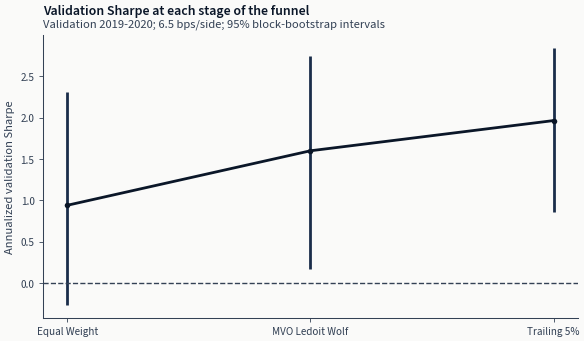

In [14]:
fig_stage, ax_stage = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
x = list(range(len(carrier)))
points = carrier["sharpe"].to_list()
lower = carrier["sharpe_ci95_lo"].to_list()
upper = carrier["sharpe_ci95_hi"].to_list()
ax_stage.errorbar(
    x,
    points,
    yerr=[
        [point - lo for point, lo in zip(points, lower, strict=True)],
        [hi - point for point, hi in zip(points, upper, strict=True)],
    ],
    marker="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    capsize=4,
    linewidth=2,
)
ax_stage.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)


_ACRONYMS = {"mvo", "hrp", "gbm", "sdf", "sae", "ipca", "lstm"}


def as_label(name: str) -> str:
    """Registry identifier rendered for a chart axis or title."""
    words = []
    for word in name.replace("_", " ").split():
        if word.lower() in _ACRONYMS:
            words.append(word.upper())
        elif word.endswith("pct") and word[:-3].isdigit():
            words.append(f"{word[:-3]}%")
        else:
            words.append(word.capitalize())
    return " ".join(words)


ax_stage.set_xticks(x, [as_label(stage) for stage in carrier["stage"].to_list()])
ax_stage.set_ylabel("Annualized validation Sharpe")
add_message_title(
    ax_stage,
    "Validation Sharpe at each stage of the funnel",
    f"Validation 2019-2020; {CONFIGURED_COST_BPS:.1f} bps/side; 95% block-bootstrap intervals",
)
fig_stage.show()

## 2. Cost survival on the same allocation lineage

The cost diagnostic is measured on the allocation lineage, before the risk rule.
Exact planned hashes keep alternate lineages and removed allocators out of the
curve.

In [15]:
cost_plans = []
for cost_bps in get_cost_grid_bps(CASE_STUDY):
    spec = set_backtest_costs_bps(
        clone_backtest_spec(base_spec),
        commission_bps=cost_bps / 2,
        slippage_bps=cost_bps / 2,
    )
    spec["chapter"] = "ch18"
    cost_plans.append(
        {
            "regime": "bps",
            "cost_value": float(cost_bps),
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

The per-share companion uses the same carrier and changes only the cost
convention.

In [16]:
for half_spread in get_cost_grid_half_spread_usd(CASE_STUDY):
    spec = set_backtest_costs_per_share(
        clone_backtest_spec(base_spec),
        per_share=get_per_share_commission(CASE_STUDY),
        default_half_spread_usd=half_spread,
    )
    spec["chapter"] = "ch18"
    cost_plans.append(
        {
            "regime": "per_share",
            "cost_value": float(half_spread),
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

In [17]:
cost_hashes = [plan["backtest_hash"] for plan in cost_plans]
with sqlite3.connect(REGISTRY_DB) as db:
    cost_metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.stage, bm.sharpe,
               bm.sharpe_ci95_lo, bm.sharpe_ci95_hi
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({",".join("?" for _ in cost_hashes)})
        """,
        connection=db,
        execute_options={"parameters": cost_hashes},
    )
cost_metrics = cost_metrics.with_columns(pl.col("backtest_hash").cast(pl.String))
cost_surface = pl.DataFrame(cost_plans).join(cost_metrics, on="backtest_hash", how="inner")
if len(cost_surface) != len(cost_plans):
    raise RuntimeError(
        f"Expected {len(cost_plans)} cost rows for carrier "
        f"{strategy_carrier['prediction_hash']}, found {len(cost_surface)}"
    )
if cost_surface.filter(pl.col("stage") != "cost_sensitivity").height:
    raise RuntimeError("A corrected cost hash has the wrong registry stage")

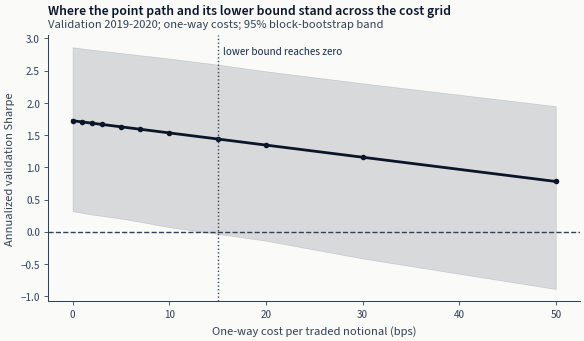

In [18]:
bps = cost_surface.filter(pl.col("regime") == "bps").sort("cost_value")


def first_zero_cost(column: str) -> float | None:
    """Lowest grid cost at which `column` reaches zero, or None if it never does."""
    reached = bps.filter(pl.col(column) <= 0)
    return reached["cost_value"].min() if reached.height else None


first_crossing = first_zero_cost("sharpe_ci95_lo")
point_crossing = first_zero_cost("sharpe")
max_bps = bps["cost_value"].max()

fig_cost, ax_cost = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
ax_cost.plot(
    bps["cost_value"],
    bps["sharpe"],
    marker="o",
    color=COLORS["blue"],
    linewidth=2,
)
ax_cost.fill_between(
    bps["cost_value"],
    bps["sharpe_ci95_lo"],
    bps["sharpe_ci95_hi"],
    color=COLORS["blue"],
    alpha=0.14,
)
ax_cost.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)
ax_cost.set_xlabel("One-way cost per traded notional (bps)")
ax_cost.set_ylabel("Annualized validation Sharpe")
if first_crossing is not None:
    ax_cost.axvline(first_crossing, color=COLORS["neutral"], linestyle=":", linewidth=1)
    ax_cost.annotate(
        "lower bound reaches zero",
        (first_crossing, ax_cost.get_ylim()[1]),
        xytext=(4, -8),
        textcoords="offset points",
        fontsize=8,
        color=COLORS["slate"],
        va="top",
    )
add_message_title(
    ax_cost,
    "Where the point path and its lower bound stand across the cost grid",
    "Validation 2019-2020; one-way costs; 95% block-bootstrap band",
)
fig_cost.show()

In [19]:
def _crossing(cost: float | None) -> str:
    return f"{cost:.0f} bps" if cost is not None else "not within the grid"


print(
    f"Lower bound first reaches zero: {_crossing(first_crossing)}; "
    f"point Sharpe first reaches zero: {_crossing(point_crossing)}; "
    f"grid runs to {max_bps:.0f} bps one-way, where point Sharpe is {bps['sharpe'][-1]:.3f}"
)

Lower bound first reaches zero: 15 bps; point Sharpe first reaches zero: not within the grid; grid runs to 50 bps one-way, where point Sharpe is 0.780


The printout above gives the cost at which each of the two first reaches zero,
or says that it does not inside the grid. The lower bound's crossing, not the
point path's, is what bounds a cost claim: a point Sharpe still above zero with
a band that straddles it is a robustness result, not an estimate of net
performance.

## 3. Paired risk effect and risk-cohort selection adjustment

The leading overlay is compared with its exact allocation baseline on aligned
timestamps. The risk-only cohort then asks how much of that apparent lead
could arise from choosing among the declared controls. It does not erase the earlier
model and allocation search, so it is a lower bound on the total search cost.

In [20]:
baseline_returns = canonical_daily_returns(strategy_carrier["backtest_hash"])
leader_returns = canonical_daily_returns(risk_leader["backtest_hash"])
if baseline_returns is None or leader_returns is None:
    raise RuntimeError("Missing daily returns for the corrected carrier")
aligned = (
    baseline_returns.rename({"ret": "baseline_ret"})
    .join(leader_returns.rename({"ret": "challenger_ret"}), on="timestamp", how="inner")
    .sort("timestamp")
)
if aligned.is_empty():
    raise RuntimeError("The overlay and its baseline are flat across the canonical window")
# `challenger_overlays_baseline` says what a flat session on the challenger means, and here
# the challenger is a risk overlay running on top of this exact carrier. Both are live from
# the carrier's first traded session, so a session the overlay sits out is a position it
# chose to hold and belongs in the comparison - it is the effect being measured. The default
# is for two independent series, where the challenger's leading zeros are a warmup before its
# first signal, and applying it here would delete the overlay's largest effect and pull
# `sharpe_diff` toward zero in the direction the overlay is under test.
paired_risk = compute_paired_uncertainty(
    aligned["challenger_ret"],
    aligned["baseline_ret"],
    periods_per_year=PERIODS_PER_YEAR,
    case_study=CASE_STUDY,
    label=LABEL,
    n_boot=2000,
    seed=SEED,
    challenger_overlays_baseline=True,
)

Selection adjustment uses only the predeclared risk overlays and keeps
the no-overlay carrier as the economic benchmark.

In [21]:
returns_by_hash = {
    backtest_hash: canonical_daily_returns(backtest_hash)
    for backtest_hash in risk_surface["backtest_hash"]
}
fold_returns_by_hash = {
    backtest_hash: load_backtest_fold_metrics(CASE_STUDY, backtest_hash=backtest_hash)[
        "sharpe"
    ].to_numpy()
    for backtest_hash in risk_surface["backtest_hash"]
}
risk_cohort = compute_cohort_metrics(
    returns_by_hash,
    periods_per_year=PERIODS_PER_YEAR,
    baseline_returns=baseline_returns,
    fold_returns_by_hash=fold_returns_by_hash,
    rademacher_n_simulations=2000,
    rademacher_seed=SEED,
)
if (
    risk_leader["risk_type"] != "none"
    and risk_cohort.get("leader_hash") != risk_leader["backtest_hash"]
):
    raise RuntimeError("Risk cohort leader does not match the corrected carrier")

In [22]:
risk_diagnostics = pl.DataFrame(
    [
        {"diagnostic": "Paired Sharpe difference", "value": paired_risk["sharpe_diff"]},
        {"diagnostic": "Paired 95% lower bound", "value": paired_risk["sharpe_diff_ci95_lo"]},
        {"diagnostic": "Paired 95% upper bound", "value": paired_risk["sharpe_diff_ci95_hi"]},
        {"diagnostic": "Bootstrap win probability", "value": paired_risk["prob_challenger_wins"]},
        {"diagnostic": "Risk-cohort DSR ER p-value", "value": risk_cohort["dsr_er_pvalue"]},
        {"diagnostic": "Risk-cohort PBO", "value": risk_cohort["pbo"]},
        {"diagnostic": "Risk-cohort folds", "value": risk_cohort["pbo_n_folds"]},
    ]
)
print(
    f"Paired improvement of {risk_leader['risk_name']} over its allocation baseline: "
    f"{paired_risk['sharpe_diff']:+.3f} "
    f"[{paired_risk['sharpe_diff_ci95_lo']:.3f}, {paired_risk['sharpe_diff_ci95_hi']:.3f}]"
)
risk_diagnostics

Paired improvement of trailing_5pct over its allocation baseline: +0.368 [-0.177, 1.007]


diagnostic,value
str,f64
"""Paired Sharpe difference""",0.367936
"""Paired 95% lower bound""",-0.177345
"""Paired 95% upper bound""",1.00711
"""Bootstrap win probability""",0.8915
"""Risk-cohort DSR ER p-value""",0.004253
"""Risk-cohort PBO""",0.5
"""Risk-cohort folds""",2.0


The paired interval above is the risk rule's own effect, measured against its
exact allocation baseline on aligned timestamps. The selection-adjusted
diagnostics in the same table account for choosing among the fixed
controls, but only two validation folds remain available for temporal
stability analysis, so the cohort statistics rest on a thin sample.

## 4. Holdout status: preserved observation, unresolved current carrier

The 2021 holdout has already been observed on an IPCA risk-adjusted-return
lineage. The corrected carrier uses a different family, label, allocation,
and risk rule, so a run on it would make the holdout another selection round.
This notebook therefore checks that no holdout prediction exists for the
corrected lineage's own training run, and reports the stored IPCA row only as
historical context.

In [23]:
with sqlite3.connect(REGISTRY_DB) as db:
    current_training_hash = db.execute(
        """
        SELECT p.training_hash
        FROM prediction_sets p
        WHERE p.prediction_hash = ?
        """,
        (strategy_carrier["prediction_hash"],),
    ).fetchone()[0]
    current_holdout_count = db.execute(
        """
        SELECT COUNT(*)
        FROM prediction_sets
        WHERE training_hash = ? AND split = 'holdout'
        """,
        (current_training_hash,),
    ).fetchone()[0]
    historical_rows = db.execute(
        """
        SELECT b.backtest_hash, t.family, t.config_name, t.label,
               b.spec_json, bm.sharpe, bm.sharpe_ci95_lo,
               bm.sharpe_ci95_hi, bm.max_drawdown
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE p.split = 'holdout'
        ORDER BY bm.sharpe DESC
        """
    ).fetchall()

In [24]:
if current_holdout_count != 0:
    raise RuntimeError("A holdout prediction unexpectedly exists for the corrected carrier")
if not historical_rows:
    raise RuntimeError("The preserved historical holdout row is missing")

historical_holdout = []
for row in historical_rows:
    spec = json.loads(row[4])
    strategy = strategy_view(spec)
    historical_holdout.append(
        {
            "backtest_hash": row[0],
            "family": row[1],
            "config": row[2],
            "label": row[3],
            "allocator": strategy.get("allocation", {}).get("method"),
            "risk": strategy.get("risk", {}).get("name"),
            "sharpe": row[5],
            "sharpe_ci_lo": row[6],
            "sharpe_ci_hi": row[7],
            "max_drawdown": row[8],
            "status": "historical, not comparable to corrected carrier",
        }
    )

print(f"Matching holdout predictions for corrected carrier: {current_holdout_count}")
pl.DataFrame(historical_holdout)

Matching holdout predictions for corrected carrier: 0


backtest_hash,family,config,label,allocator,risk,sharpe,sharpe_ci_lo,sharpe_ci_hi,max_drawdown,status
str,str,null,str,str,str,f64,f64,f64,f64,str
"""7dee1768fd9f""","""latent_factors""",null,"""fwd_ret_5d""","""mvo_ledoit_wolf""","""trailing_5pct""",1.545315,-0.485329,3.682673,-0.114635,"""historical, not comparable to …"


The stored holdout rows above sit on an IPCA risk-adjusted-return lineage.
They neither validate nor refute the corrected carrier, which uses a
different family, label, allocation, and risk rule. The current carrier's
out-of-sample status is unresolved and needs a future untouched evaluation
window.

## 5. Publication assessment

The corrected validation record is internally closed: every planned
allocation, cost, and risk hash exists and the selected risk result
reproduces exactly. Closed is not the same as favorable. The gate table below
reports each check on its own terms, and the paired risk interval is the one
to read carefully. The remaining gap is not a computation failure: it is the
deliberate absence of a second use of the already-observed holdout.

In [25]:
final_row = carrier.row(len(carrier) - 1, named=True)
stress = bps.sort("cost_value").row(len(bps) - 1, named=True)
assessment = pl.DataFrame(
    [
        {
            "gate": "Corrected validation carrier",
            "status": "PASS",
            "evidence": (
                f"{carrier_family}/{carrier_config} / {strategy_carrier['allocator']} / "
                f"top {strategy_carrier['top_k']} / {risk_leader['risk_name']}"
            ),
        },
        {
            "gate": "Validation Sharpe uncertainty",
            "status": "PASS" if final_row["sharpe_ci95_lo"] > 0 else "INCONCLUSIVE",
            "evidence": (
                f"{final_row['sharpe']:.3f} "
                f"[{final_row['sharpe_ci95_lo']:.3f}, {final_row['sharpe_ci95_hi']:.3f}]"
            ),
        },
        {
            "gate": "Paired risk improvement",
            "status": "PASS" if paired_risk["sharpe_diff_ci95_lo"] > 0 else "INCONCLUSIVE",
            "evidence": (
                f"{paired_risk['sharpe_diff']:+.3f} "
                f"[{paired_risk['sharpe_diff_ci95_lo']:.3f}, "
                f"{paired_risk['sharpe_diff_ci95_hi']:.3f}]"
            ),
        },
        {
            "gate": f"{stress['cost_value']:.0f} bps point stress",
            "status": "PASS" if stress["sharpe"] > 0 else "FAIL",
            "evidence": (
                f"Sharpe {stress['sharpe']:.3f} "
                f"[{stress['sharpe_ci95_lo']:.3f}, {stress['sharpe_ci95_hi']:.3f}]"
            ),
        },
        {
            "gate": "Matching untouched holdout",
            "status": "UNRESOLVED",
            "evidence": "not run; 2021 holdout already observed on IPCA",
        },
        {
            "gate": "Deployment claim",
            "status": "FAIL",
            "evidence": "validation-positive is not out-of-sample efficacy",
        },
    ]
)
assessment

gate,status,evidence
str,str,str
"""Corrected validation carrier""","""PASS""","""latent_factors/sae / mvo_ledoi…"
"""Validation Sharpe uncertainty""","""PASS""","""1.966 [0.857, 2.844]"""
"""Paired risk improvement""","""INCONCLUSIVE""","""+0.368 [-0.177, 1.007]"""
"""50 bps point stress""","""PASS""","""Sharpe 0.780 [-0.889, 1.949]"""
"""Matching untouched holdout""","""UNRESOLVED""","""not run; 2021 holdout already …"
"""Deployment claim""","""FAIL""","""validation-positive is not out…"


## Key takeaways

1. The corrected v3.1 validation carrier is the model, allocator, top-k, and
   risk rule named in the assessment table above. Eligibility is decided by
   coverage of the canonical validation window, so a checkpoint whose extra
   decision dates fall outside that window earns no advantage.
2. The stage chart shows Sharpe at each stage the funnel actually produced,
   which is between one and three points depending on whether allocation and
   the risk rule each improved on what came before. The interval at every
   stage is wide: the point path moves far more than the uncertainty around it
   narrows.
3. The risk rule's paired improvement is reported with its own interval
   against the exact allocation baseline. Selection adjustment covers the fixed
   controls, but only two validation folds remain for stability analysis.
4. The cost curve is read from its lower bound, not its point path. The cell
   under the cost chart reports where each first reaches zero, and the lower
   bound's crossing is the one a cost claim has to respect.
5. The existing IPCA holdout rows are historical and not comparable to the
   corrected carrier. No matching holdout was run, because the 2021 window
   has already been observed.
6. Publication may present v3.1 as a corrected validation record, but it must
   label out-of-sample efficacy unresolved and make no deployment claim.